In [ ]:
!pip install qiskit_optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.5/646.5 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.7 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.30.251-py3-none-any.whl size=685954 sha256=d48320c7aca101bfb78ca4452b9d21978d2ecf8f4c5883f7df0c865ec9feb235
  Stored in directory: /root/.cache/pip/wheels/c1/d9/5c/1d919b1e441ebbaff244513a13d09c3c0378401601d4184bb0
Successfully built docplex


In [ ]:

import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

In [ ]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
import networkx as nx
import matplotlib.pyplot as plt

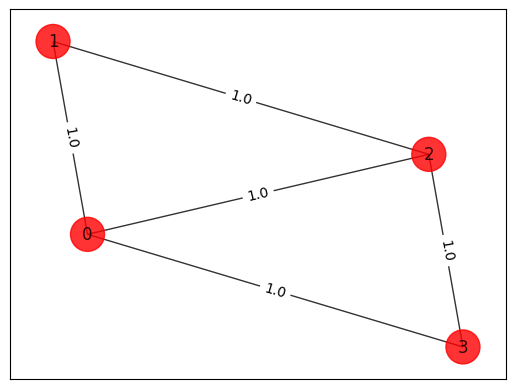

In [ ]:
n = 4  # Number of nodes in graph
G = nx.Graph()
G.add_nodes_from(np.arange(0, n, 1))
elist = [(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (2, 3, 1.0)]
# tuple is (i,j,weight) where (i,j) is the edge
G.add_weighted_edges_from(elist)

colors = ["r" for node in G.nodes()]
pos = nx.spring_layout(G)


def draw_graph(G, colors, pos):
    default_axes = plt.axes(frameon=True)
    nx.draw_networkx(G, node_color=colors, node_size=600, alpha=0.8, ax=default_axes, pos=pos)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)


draw_graph(G, colors, pos)

Weight Matrix;

In [ ]:
w= np.zeros([n,n])
for i in range(n):
    for j in range(n):
        temp = G.get_edge_data(i, j, default=0)
        if temp != 0:
            w[i, j] = temp["weight"]
print(w)

[[0. 1. 1. 1.]
 [1. 0. 1. 0.]
 [1. 1. 0. 1.]
 [1. 0. 1. 0.]]


In [ ]:
from qiskit_optimization.applications import Maxcut, Tsp

The easy way to implemnt max cut from the weight matrix

In [ ]:
max_cut = Maxcut(w)
qp = max_cut.to_quadratic_program()
print(qp.prettyprint())

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_2 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 3*x_0 + 2*x_1
  + 3*x_2 + 2*x_3

Subject to
  No constraints

  Binary variables (4)
    x_0 x_1 x_2 x_3



Exact solution with Numpy

In [ ]:
exact_mes = NumPyMinimumEigensolver()
exact = MinimumEigenOptimizer(exact_mes)  # using the exact classical numpy minimum eigen solver
result = exact.solve(qp)
print(result.prettyprint())

objective function value: 4.0
variable values: x_0=1.0, x_1=0.0, x_2=1.0, x_3=0.0
status: SUCCESS


State Vector Sampler(nosiness simulator)

In [ ]:
from qiskit_optimization.utils import algorithm_globals
algorithm_globals.random_seed = 10598
qaoa_mes = QAOA(
    sampler=StatevectorSampler(seed=123), optimizer=COBYLA(),
    initial_point=[1, 1])

In [ ]:
qaoa = MinimumEigenOptimizer(qaoa_mes)
qaoa_result = qaoa.solve(qp)
print(qaoa_result.prettyprint())

objective function value: 4.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0
status: SUCCESS


In [ ]:
def get_filtered_samples(
    samples: list[SolutionSample],
    threshold: float = 0,
    allowed_status: tuple[OptimizationResultStatus] = (OptimizationResultStatus.SUCCESS,),
):
    res = []
    for s in samples:
        if s.status in allowed_status and s.probability > threshold:
            res.append(s)

    return res

In [ ]:
filtered_samples = get_filtered_samples(
    qaoa_result.samples, threshold=0.005, allowed_status=(OptimizationResultStatus.SUCCESS,)
)
for s in filtered_samples:
    print(s)

SolutionSample(x=array([0., 1., 0., 1.]), fval=np.float64(4.0), probability=0.2216796875, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 0., 1., 0.]), fval=np.float64(4.0), probability=0.224609375, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 0., 0., 0.]), fval=np.float64(3.0), probability=0.0361328125, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0., 0., 1., 0.]), fval=np.float64(3.0), probability=0.0390625, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 1., 0., 1.]), fval=np.float64(3.0), probability=0.0283203125, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 0., 0., 1.]), fval=np.float64(3.0), probability=0.033203125, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0., 0., 1., 1.]), fval=np.float64(3.0), probability=0.0322265625, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 1., 0., 0.]), fval=np.flo

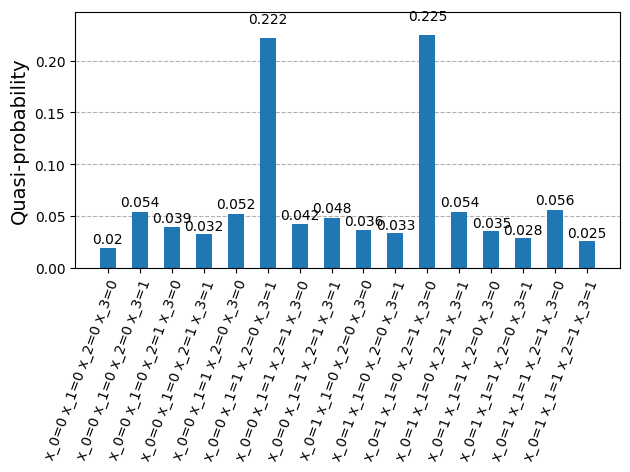

In [ ]:
fvals = [s.fval for s in qaoa_result.samples]
probabilities = [s.probability for s in qaoa_result.samples]
samples_for_plot = {
    " ".join(f"{qaoa_result.variables[i].name}={int(v)}" for i, v in enumerate(s.x)): s.probability
    for s in filtered_samples
}
samples_for_plot
plot_histogram(samples_for_plot)

In [ ]:
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.9 MB/s eta 0:00:00


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2


In [ ]:
rqaoa = RecursiveMinimumEigenOptimizer(qaoa, min_num_vars=1, min_num_vars_optimizer=exact)

In [ ]:
rqaoa_result = rqaoa.solve(qp)
print(rqaoa_result.prettyprint())

objective function value: 4.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0
status: SUCCESS


In [ ]:
filtered_samples = get_filtered_samples(
    rqaoa_result.samples, threshold=0.005, allowed_status=(OptimizationResultStatus.SUCCESS,)
)
samples_for_plot = {
    " ".join(f"{rqaoa_result.variables[i].name}={int(v)}" for i, v in enumerate(s.x)): s.probability
    for s in filtered_samples
}
samples_for_plot

{'x_0=0 x_1=1 x_2=0 x_3=1': 1.0}

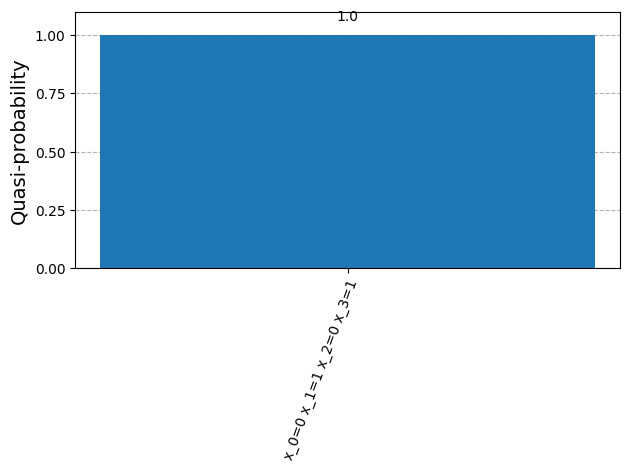

In [ ]:
plot_histogram(samples_for_plot)

**TRAVELING SALESMAN**

In [ ]:
tsp = Tsp.create_random_instance(3, seed= 123)
adj_matrix = nx.to_numpy_array(tsp.graph)
print(adj_matrix)

[[ 0. 48. 91.]
 [48.  0. 63.]
 [91. 63.  0.]]


In [ ]:
qp2 = tsp.to_quadratic_program()
print(qp2.prettyprint())

Problem name: TSP

Minimize
  48*x_0_0*x_1_1 + 48*x_0_0*x_1_2 + 91*x_0_0*x_2_1 + 91*x_0_0*x_2_2
  + 48*x_0_1*x_1_0 + 48*x_0_1*x_1_2 + 91*x_0_1*x_2_0 + 91*x_0_1*x_2_2
  + 48*x_0_2*x_1_0 + 48*x_0_2*x_1_1 + 91*x_0_2*x_2_0 + 91*x_0_2*x_2_1
  + 63*x_1_0*x_2_1 + 63*x_1_0*x_2_2 + 63*x_1_1*x_2_0 + 63*x_1_1*x_2_2
  + 63*x_1_2*x_2_0 + 63*x_1_2*x_2_1

Subject to
  Linear constraints (6)
    x_0_0 + x_0_1 + x_0_2 == 1  'c0'
    x_1_0 + x_1_1 + x_1_2 == 1  'c1'
    x_2_0 + x_2_1 + x_2_2 == 1  'c2'
    x_0_0 + x_1_0 + x_2_0 == 1  'c3'
    x_0_1 + x_1_1 + x_2_1 == 1  'c4'
    x_0_2 + x_1_2 + x_2_2 == 1  'c5'

  Binary variables (9)
    x_0_0 x_0_1 x_0_2 x_1_0 x_1_1 x_1_2 x_2_0 x_2_1 x_2_2



In [ ]:
from qiskit_optimization.converters import QuadraticProgramToQubo

qp2qubo = QuadraticProgramToQubo()
qubo = qp2qubo.convert(qp2)
qubitOp, offset = qubo.to_ising()
print("Offset:", offset)
print("Ising Hamiltonian:")
print(str(qubitOp))


Offset: 7581.0
Ising Hamiltonian:
SparsePauliOp(['IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', 'IIIIZIIIZ', 'IIIZIIIIZ', 'IIZIIIIIZ', 'IZIIIIIIZ', 'ZIIIIIIIZ', 'IIIIIIZZI', 'IIIIIZIZI', 'IIIIZIIZI', 'IIIZIIIZI', 'IIZIIIIZI', 'IZIIIIIZI', 'ZIIIIIIZI', 'IIIIIZZII', 'IIIIZIZII', 'IIIZIIZII', 'IIZIIIZII', 'IZIIIIZII', 'ZIIIIIZII', 'IIIIZZIII', 'IIIZIZIII', 'IIZIIZIII', 'IZIIIZIII', 'ZIIIIZIII', 'IIIZZIIII', 'IIZIZIIII', 'IZIIZIIII', 'ZIIIZIIII', 'IIZZIIIII', 'IZIZIIIII', 'ZIIZIIIII', 'IZZIIIIII', 'ZIZIIIIII', 'ZZIIIIIII'],
              coeffs=[-1282.5 +0.j, -1282.5 +0.j, -1282.5 +0.j, -1268.5 +0.j, -1268.5 +0.j,
 -1268.5 +0.j, -1290.  +0.j, -1290.  +0.j, -1290.  +0.j,   606.5 +0.j,
   606.5 +0.j,   606.5 +0.j,    12.  +0.j,    12.  +0.j,   606.5 +0.j,
    22.75+0.j,    22.75+0.j,   606.5 +0.j,    12.  +0.j,   606.5 +0.j,
    12.  +0.j,    22.75+0.j,   606.5 +0.j,    22.75+0.j,    

In [ ]:
print(qubo.prettyprint())

Problem name: TSP

Minimize
  2426*x_0_0^2 + 2426*x_0_0*x_0_1 + 2426*x_0_0*x_0_2 + 2426*x_0_0*x_1_0
  + 48*x_0_0*x_1_1 + 48*x_0_0*x_1_2 + 2426*x_0_0*x_2_0 + 91*x_0_0*x_2_1
  + 91*x_0_0*x_2_2 + 2426*x_0_1^2 + 2426*x_0_1*x_0_2 + 48*x_0_1*x_1_0
  + 2426*x_0_1*x_1_1 + 48*x_0_1*x_1_2 + 91*x_0_1*x_2_0 + 2426*x_0_1*x_2_1
  + 91*x_0_1*x_2_2 + 2426*x_0_2^2 + 48*x_0_2*x_1_0 + 48*x_0_2*x_1_1
  + 2426*x_0_2*x_1_2 + 91*x_0_2*x_2_0 + 91*x_0_2*x_2_1 + 2426*x_0_2*x_2_2
  + 2426*x_1_0^2 + 2426*x_1_0*x_1_1 + 2426*x_1_0*x_1_2 + 2426*x_1_0*x_2_0
  + 63*x_1_0*x_2_1 + 63*x_1_0*x_2_2 + 2426*x_1_1^2 + 2426*x_1_1*x_1_2
  + 63*x_1_1*x_2_0 + 2426*x_1_1*x_2_1 + 63*x_1_1*x_2_2 + 2426*x_1_2^2
  + 63*x_1_2*x_2_0 + 63*x_1_2*x_2_1 + 2426*x_1_2*x_2_2 + 2426*x_2_0^2
  + 2426*x_2_0*x_2_1 + 2426*x_2_0*x_2_2 + 2426*x_2_1^2 + 2426*x_2_1*x_2_2
  + 2426*x_2_2^2 - 4852*x_0_0 - 4852*x_0_1 - 4852*x_0_2 - 4852*x_1_0
  - 4852*x_1_1 - 4852*x_1_2 - 4852*x_2_0 - 4852*x_2_1 - 4852*x_2_2 + 7278

Subject to
  No constraints

  Binary va

In [ ]:
exact_mes = NumPyMinimumEigensolver()
exact = MinimumEigenOptimizer(exact_mes)  # using the exact classical numpy minimum eigen solver
result = exact.solve(qubo)
print(result.prettyprint())


objective function value: 202.0
variable values: x_0_0=1.0, x_0_1=0.0, x_0_2=0.0, x_1_0=0.0, x_1_1=1.0, x_1_2=0.0, x_2_0=0.0, x_2_1=0.0, x_2_2=1.0
status: SUCCESS


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

In [ ]:
from qiskit_optimization.minimum_eigensolvers.minimum_eigensolver import MinimumEigensolver
from qiskit.transpiler.passes import optimization
pass_manager = generate_preset_pass_manager(optimization_level = 2 , backend = AerSimulator())

qaoa_noisy = QAOA(
    sampler = SamplerV2(), optimizer=COBYLA(),
    initial_point=[1, 1], pass_manager = pass_manager)
meo_noisy = MinimumEigenOptimizer(qaoa_noisy)
result = meo_noisy.solve(qubo)

objective function value: 202.0
variable values: x_0_0=1.0, x_0_1=0.0, x_0_2=0.0, x_1_0=0.0, x_1_1=0.0, x_1_2=1.0, x_2_0=0.0, x_2_1=1.0, x_2_2=0.0
status: SUCCESS


/usr/local/lib/python3.12/dist-packages/qiskit/visualization/counts_visualization.py:412: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


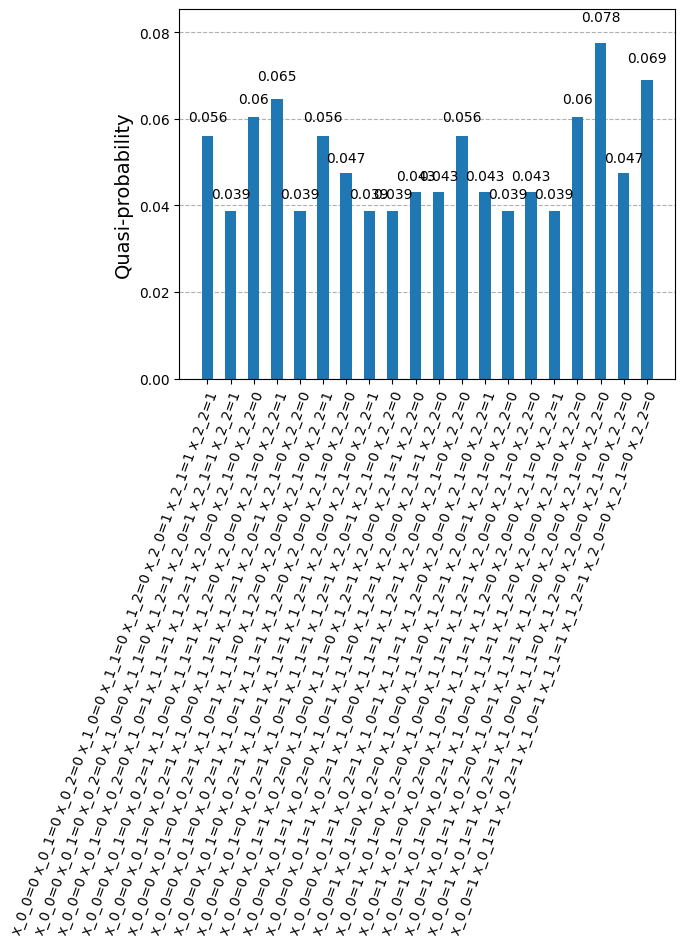

In [ ]:
print(result.prettyprint())
filtered_samples = get_filtered_samples(
    result.samples, threshold=0.008, allowed_status=(OptimizationResultStatus.SUCCESS,)
)
samples_for_plot = {
    " ".join(f"{result.variables[i].name}={int(v)}" for i, v in enumerate(s.x)): s.probability
    for s in filtered_samples
}
plot_histogram(samples_for_plot)

In [ ]:
print(result)

fval=202.0, x_0_0=1.0, x_0_1=0.0, x_0_2=0.0, x_1_0=0.0, x_1_1=0.0, x_1_2=1.0, x_2_0=0.0, x_2_1=1.0, x_2_2=0.0, status=SUCCESS
